<a href="https://colab.research.google.com/github/GitNinja4/Celebal-DS_Internship/blob/main/Week4_Aditya_Anand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [12]:
# TensorFlow is the main deep learning framework we use to build and train models
import tensorflow as tf

# 'layers' gives us building blocks like Dense, Conv2D, Dropout etc.
# 'models' lets us stack those layers into a Sequential model
# 'callbacks' provides utilities like EarlyStopping that run during training
from tensorflow.keras import layers, models, callbacks

# matplotlib for plotting training curves and sample images
import matplotlib.pyplot as plt

# numpy for numerical operations (e.g. reshaping arrays)
import numpy as np

# pandas for creating the final comparison table
import pandas as pd

print('TensorFlow version:', tf.__version__)

# Set random seeds so results are reproducible every time we run the notebook
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [13]:
# Keras has CIFAR-10 built-in — this downloads it automatically on first run
# It returns two tuples: (training images, training labels) and (test images, test labels)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Class names in the order CIFAR-10 uses them (index 0 = airplane, index 9 = truck)
# We use this list to convert numeric labels to human-readable names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Verify data was loaded correctly
# Expected: x_train → (50000, 32, 32, 3) meaning 50000 images of 32x32 pixels with 3 color channels (RGB)
print('Train shape:', x_train.shape, '| Labels:', y_train.shape)
print('Test shape :', x_test.shape,  '| Labels:', y_test.shape)

# Confirm pixel values are in range 0-255 before we normalize them
print('Pixel range before norm: [{}, {}]'.format(x_train.min(), x_train.max()))

Train shape: (50000, 32, 32, 3) | Labels: (50000, 1)
Test shape : (10000, 32, 32, 3) | Labels: (10000, 1)
Pixel range before norm: [0, 255]


## 🖼️ Visualize Sample Images

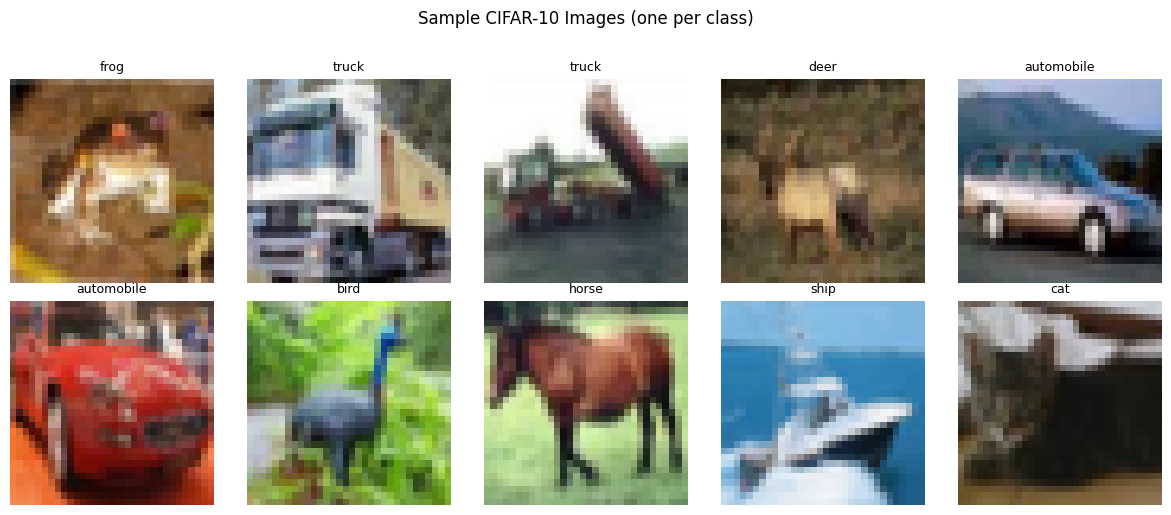

In [14]:
# Create a 2-row x 5-column grid to show 10 sample images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i+1)      # Position i+1 in a 2x5 grid
    plt.imshow(x_train[i])      # Show the raw image (pixels 0-255, matplotlib handles it)
    plt.title(class_names[y_train[i][0]], fontsize=9)  # y_train[i] is shape (1,) so we index [0]
    plt.axis('off')              # Hide the x/y axis ticks — not needed for images

plt.suptitle('Sample CIFAR-10 Images (one per class)', fontsize=12, y=1.02)
plt.tight_layout()  # Automatically adjust subplot spacing to avoid overlap
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [15]:
# --- Step 1: Normalize pixel values ---
# Original values are integers 0-255; we divide by 255 to get floats in range 0.0-1.0
# Why? Neural networks train faster and more stably when inputs are small numbers
# We cast to float32 first because the raw data is uint8 (integer), which can't store decimals
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# --- Step 2: Flatten images for ANN input ---
# ANN cannot accept 2D/3D images — it only takes 1D vectors
# reshape(..., -1) flattens everything after the batch dimension
# (50000, 32, 32, 3) → (50000, 3072)   because 32 * 32 * 3 = 3072
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

# Verify final shapes
print('Normalized shape (CNN input):', x_train_norm.shape)
print('Flattened shape  (ANN input):', x_train_flat.shape)

Normalized shape (CNN input): (50000, 32, 32, 3)
Flattened shape  (ANN input): (50000, 3072)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [16]:
# Sequential means layers are stacked one after another (left to right)
ann_model = models.Sequential([

    # Hidden Layer 1: 512 neurons
    # input_shape=(3072,) tells Keras the size of one flattened image
    # ReLU activation: outputs max(0, x) — introduces non-linearity so the model can learn complex patterns
    layers.Dense(512, activation='relu', input_shape=(3072,)),

    # Dropout: during training, randomly sets 30% of neuron outputs to zero
    # This prevents overfitting by forcing the network not to rely on any single neuron
    layers.Dropout(0.3),

    # Hidden Layer 2: 256 neurons — gradually shrinking size is a common design choice
    layers.Dense(256, activation='relu'),

    # Output Layer: 10 neurons (one per class)
    # Softmax converts raw scores into probabilities that sum to 1.0
    # e.g. [0.05, 0.70, 0.03, ...] → model is 70% confident it's class index 1 (automobile)
    layers.Dense(10, activation='softmax')

], name='ANN')

ann_model.compile(
    optimizer='adam',                        # Adam adapts the learning rate automatically — good default choice
    loss='sparse_categorical_crossentropy',  # Use this when labels are integers (0-9), not one-hot encoded
    metrics=['accuracy']                     # Track accuracy alongside loss during training
)

# Print a layer-by-layer summary showing output shapes and parameter counts
ann_model.summary()

Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# EarlyStopping stops training if val_accuracy doesn't improve for 3 consecutive epochs
# restore_best_weights=True: after stopping, it reloads the weights from the best epoch (not the last)
# This prevents us from saving an overfit model from the final epoch
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',   # Watch validation accuracy (not training accuracy)
    patience=3,               # Wait 3 epochs before stopping if no improvement
    restore_best_weights=True
)

# Train the ANN
ann_history = ann_model.fit(
    x_train_flat, y_train,   # Flattened input for ANN
    epochs=15,               # Train for up to 15 passes through the full dataset
    validation_split=0.1,    # Hold out 10% of training data (5000 images) to monitor overfitting
    batch_size=64,           # Process 64 images at a time before updating weights
    callbacks=[early_stop],  # Pass in early stopping
    verbose=1                # Print progress for each epoch
)

# Evaluate on the test set (data the model has never seen)
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f'\nANN Test Accuracy : {ann_test_acc:.4f}')
print(f'ANN Test Loss     : {ann_test_loss:.4f}')

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.2666 - loss: 2.0047 - val_accuracy: 0.3368 - val_loss: 1.8459
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3113 - loss: 1.8849 - val_accuracy: 0.3510 - val_loss: 1.8068
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3357 - loss: 1.8231 - val_accuracy: 0.3586 - val_loss: 1.7882
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.3452 - loss: 1.7969 - val_accuracy: 0.3864 - val_loss: 1.7461
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3556 - loss: 1.7641 - val_accuracy: 0.3852 - val_loss: 1.7202
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3615 - loss: 1.7536 - val_accuracy: 0.3970 - val_loss: 1.6934
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3686 - loss: 1.7375 - val_accuracy: 0.4008 - val_loss: 1.6921
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3741 - loss: 1.7165 - 

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [18]:
cnn_model = models.Sequential([

    # BLOCK 1
    # Conv2D: 32 filters, each of size 3x3
    # Each filter slides over the image and learns to detect a specific feature (e.g. a horizontal edge)
    # padding='same' keeps output spatial size the same as input (32x32 stays 32x32)
    # input_shape=(32,32,3): height=32, width=32, channels=3 (RGB)
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),

    # BatchNormalization: normalizes the output of the conv layer across the batch
    # This stabilizes training and lets us use higher learning rates
    layers.BatchNormalization(),

    # MaxPooling2D: takes 2x2 windows and keeps only the max value
    # Reduces spatial size from 32x32 → 16x16, making features more abstract and computation cheaper
    layers.MaxPooling2D((2,2)),

    # BLOCK 2
    # 64 filters now — we increase depth as spatial size shrinks
    # This block learns more complex combinations of the features from Block 1
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),   # 16x16 → 8x8

    # BLOCK 3
    # 128 filters — highest-level feature extraction
    # No pooling here: we want to preserve some spatial info before flattening
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # CLASSIFIER HEAD
    # Flatten: convert the 3D feature map (8x8x128) into a 1D vector (8192,)
    # This bridges the convolutional part and the fully-connected part
    layers.Flatten(),

    # Dense layer: takes all extracted features and learns which combinations predict which class
    layers.Dense(128, activation='relu'),

    # Dropout: randomly drops 40% of neurons to prevent overfitting in the dense layer
    layers.Dropout(0.4),

    # Output: 10 neurons with Softmax → probability distribution across 10 classes
    layers.Dense(10, activation='softmax')

], name='CNN')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
# Fresh EarlyStopping for CNN — completely independent from ANN's callback
# patience=5 gives the model enough room to recover from a bad validation epoch
cnn_history = cnn_model.fit(
    x_train_norm, y_train,   # 3D normalized input: (50000, 32, 32, 3)
    epochs=15,
    validation_split=0.1,    # 10% held out for validation
    batch_size=64,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

# Evaluate on test set
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f'\nCNN Test Accuracy : {cnn_test_acc:.4f}')
print(f'CNN Test Loss     : {cnn_test_loss:.4f}')

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 149s 211ms/step - accuracy: 0.7918 - loss: 0.5958 - val_accuracy: 0.6470 - val_loss: 1.1431
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 210ms/step - accuracy: 0.8197 - loss: 0.5048 - val_accuracy: 0.6954 - val_loss: 0.9820
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 209ms/step - accuracy: 0.8446 - loss: 0.4370 - val_accuracy: 0.7008 - val_loss: 0.9761
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 207ms/step - accuracy: 0.8628 - loss: 0.3833 - val_accuracy: 0.7480 - val_loss: 0.9057
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 206ms/step - accuracy: 0.8788 - loss: 0.3374 - val_accuracy: 0.7438 - val_loss: 0.9286
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 209ms/step - accuracy: 0.8905 - loss: 0.3030 - val_accuracy: 0.6668 - val_loss: 1.2981
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 210ms/step - accuracy: 0.8993 - loss: 0.2794 - val_accuracy: 0.7538 - val_loss: 0.9547
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 147s 208ms/step - accuracy: 0.9096 -

## 📈 Compare Learning Curves

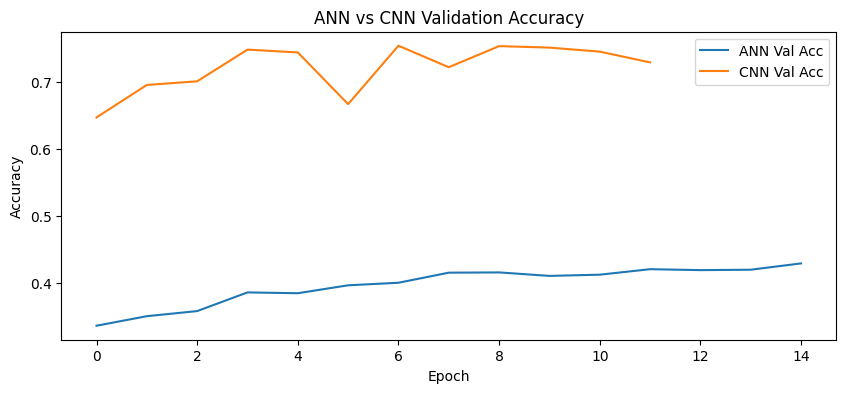

In [22]:
# Compare ANN vs CNN validation accuracy on a single chart
# This is the key visual that shows WHY CNN outperforms ANN on image tasks
plt.figure(figsize=(10, 4))

# val_accuracy = accuracy measured on the held-out 10% validation set each epoch
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ANN vs CNN Validation Accuracy')
plt.legend()
plt.show()


# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [23]:
# Define augmentation as a small Sequential pipeline
# These transforms are applied randomly during training only — not at test time
# This means each epoch the model sees slightly different versions of the same image
data_augmentation = tf.keras.Sequential([

    # Randomly flip image left-to-right with 50% probability
    # Makes sense for CIFAR-10: a car facing left is still a car
    layers.RandomFlip('horizontal'),

    # Randomly rotate by up to 10% of 360° = up to ~36 degrees
    # Helps model be invariant to object orientation
    layers.RandomRotation(0.1),

    # Randomly zoom in or out by up to 10%
    # Helps model handle objects at different scales
    layers.RandomZoom(0.1)

], name='augmentation')

# Build the Aug-CNN: same architecture as CNN, but augmentation is added as the first step
aug_cnn_model = models.Sequential([

    # Augmentation layer: applied only during model.fit(), skipped during model.evaluate()
    data_augmentation,

    # Block 1: detect low-level features (edges, color blobs)
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),   # 32x32 → 16x16

    # Block 2: detect mid-level features (corners, textures)
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),   # 16x16 → 8x8

    # Block 3: detect high-level features (object parts)
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Flatten and classify
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),           # Stronger dropout (0.4) since augmentation already helps regularize
    layers.Dense(10, activation='softmax')

], name='Aug_CNN')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "Aug_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fresh EarlyStopping for Aug-CNN
# Higher patience (6) because augmented data introduces more epoch-to-epoch variance
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,             # Higher ceiling — augmentation slows convergence
    validation_split=0.1,
    batch_size=64,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=6,               # More patience for augmented training
            restore_best_weights=True
        )
    ],
    verbose=1
)

# Augmentation is automatically disabled during evaluate()
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f'\nAug-CNN Test Accuracy : {aug_test_acc:.4f}')
print(f'Aug-CNN Test Loss     : {aug_test_loss:.4f}')


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 170s 241ms/step - accuracy: 0.3941 - loss: 1.6610 - val_accuracy: 0.4618 - val_loss: 1.4660
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 197s 234ms/step - accuracy: 0.4782 - loss: 1.4476 - val_accuracy: 0.5436 - val_loss: 1.2980
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 165s 234ms/step - accuracy: 0.5270 - loss: 1.3274 - val_accuracy: 0.5810 - val_loss: 1.2998
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 233ms/step - accuracy: 0.5643 - loss: 1.2352 - val_accuracy: 0.4998 - val_loss: 1.8544
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 163s 232ms/step - accuracy: 0.5883 - loss: 1.1740 - val_accuracy: 0.6100 - val_loss: 1.2330
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 169s 239ms/step - accuracy: 0.6113 - loss: 1.1109 - val_accuracy: 0.6486 - val_loss: 1.0553
Epoch 7/20
 33/704 ━━━━━━━━━━━━━━━━━━━━ 2:27 220ms/step - accuracy: 0.6264 - loss: 1.1018

In [ ]:
# Create a side-by-side plot: accuracy on left, loss on right
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Plot: Validation Accuracy ---
# history.history is a dict of metric lists recorded after each epoch
# 'val_accuracy' = accuracy on the 10% held-out validation set
axes[0].plot(ann_history.history['val_accuracy'],     label='ANN',     marker='o', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'],     label='CNN',     marker='s', linewidth=2)
axes[0].plot(aug_history.history['val_accuracy'],     label='Aug-CNN', marker='^', linewidth=2)
axes[0].set_title('Validation Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Right Plot: Validation Loss ---
# Lower loss = better; CNN curves should drop faster and stay lower than ANN
axes[1].plot(ann_history.history['val_loss'],     label='ANN',     marker='o', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'],     label='CNN',     marker='s', linewidth=2)
axes[1].plot(aug_history.history['val_loss'],     label='Aug-CNN', marker='^', linewidth=2)
axes[1].set_title('Validation Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Dynamics: ANN vs CNN vs Aug-CNN', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# 📊 Final Comparison Table

In [ ]:
# Build a summary DataFrame with all three model results
comparison = pd.DataFrame({
    'Model'        : ['ANN', 'CNN', 'Aug-CNN'],
    'Test Accuracy': [round(ann_test_acc,4), round(cnn_test_acc,4), round(aug_test_acc,4)],
    'Test Loss'    : [round(ann_test_loss,4), round(cnn_test_loss,4), round(aug_test_loss,4)],
    'Key Technique': ['Fully Connected', 'Conv + BatchNorm + Pool', 'CNN + Augmentation + EarlyStopping']
})

# Set 'Model' as the row index for cleaner display
comparison.set_index('Model', inplace=True)

# Use pandas Styler to highlight the best values in green
# highlight_max on accuracy (higher is better) and highlight_min on loss (lower is better)
comparison.style.highlight_max(subset=['Test Accuracy'], color='lightgreen') \
                .highlight_min(subset=['Test Loss'],     color='lightgreen')

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**